# Previsão de Churn — Principais Insights para o Negócio

**Versão para apresentação ao time de retenção.** Este notebook reúne os achados e
simulações mais relevantes para decisão de negócio, com a explicação do valor gerado por
cada um. A análise técnica completa (comparação de modelos, validação cruzada,
diagnóstico estatístico, checagens de qualidade) está no notebook técnico
(`churn_notebook.ipynb`) — aqui vamos direto ao que importa para agir.

**Como rodar:** execute todas as células em ordem (Run All / Executar tudo). Este
notebook carrega o modelo já treinado (`artefatos_modelo/pipeline_churn.pkl`) em vez de
retreinar do zero, então roda em segundos.

> **Nota sobre como rodar este notebook:** a célula abaixo procura os arquivos do modelo
> automaticamente em vários lugares comuns. Se você estiver no **Google Colab**, o ambiente
> do Colab é uma máquina na nuvem separada do seu computador — ele **não enxerga sua pasta
> `churn` da Área de Trabalho sozinho**. Quando a célula não encontrar os arquivos, ela vai
> abrir uma caixa de upload automaticamente: basta selecionar os 5 arquivos
> (`pipeline_churn.pkl`, `metadados.json`, `pipeline_clusters.pkl`, `metadados_clusters.json`
> — todos dentro de `artefatos_modelo` — e `TelcoCustomerChurn.csv`, na raiz da pasta
> `churn`) quando ela aparecer.
>
> Se estiver rodando no **Jupyter local** (instalado no seu computador), basta garantir que
> o notebook esteja dentro da pasta `churn`, junto com a subpasta `artefatos_modelo` e o
> `TelcoCustomerChurn.csv` — a busca automática deve funcionar sem precisar fazer nada.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Localização automática dos arquivos do modelo (funciona tanto rodando localmente
# quanto no Google Colab, onde o notebook não tem acesso direto ao seu computador) ---
try:
    import google.colab
    EM_COLAB = True
except ImportError:
    EM_COLAB = False


def _pastas_candidatas():
    bases = [os.getcwd()]
    try:
        dh = globals().get("_dh")
        if dh:
            bases.append(str(dh[0]))
    except Exception:
        pass
    bases += [os.path.join(b, "churn") for b in list(bases)]
    bases += [r"C:\Users\ti_ez\Desktop\churn"]  # caminho conhecido deste projeto
    vistas, unicas = set(), []
    for b in bases:
        if b and b not in vistas:
            vistas.add(b)
            unicas.append(b)
    return unicas


def _achar_arquivo(nome_arquivo, subpasta="artefatos_modelo"):
    for base in _pastas_candidatas():
        for caminho in (os.path.join(base, subpasta, nome_arquivo), os.path.join(base, nome_arquivo)):
            if os.path.exists(caminho):
                return caminho
    return None


# Todos os arquivos que este notebook precisa -- os 4 primeiros ficam em 'artefatos_modelo',
# o CSV fica na raiz da pasta 'churn'.
ARQUIVOS_NECESSARIOS = {
    "pipeline_churn.pkl": None,
    "metadados.json": None,
    "pipeline_clusters.pkl": None,
    "metadados_clusters.json": None,
    "TelcoCustomerChurn.csv": None,
}
for _nome in ARQUIVOS_NECESSARIOS:
    _subpasta = "." if _nome.endswith(".csv") else "artefatos_modelo"
    ARQUIVOS_NECESSARIOS[_nome] = _achar_arquivo(_nome, subpasta=_subpasta)

if EM_COLAB and any(v is None for v in ARQUIVOS_NECESSARIOS.values()):
    faltando_colab = [n for n, v in ARQUIVOS_NECESSARIOS.items() if v is None]
    print("Rodando no Google Colab: não encontrei automaticamente os seguintes arquivos")
    print("(o Colab não tem acesso direto ao seu computador):")
    for _n in faltando_colab:
        print("  -", _n)
    print("Selecione todos eles de uma vez na caixa de upload que vai aparecer.")
    from google.colab import files
    enviados = files.upload()
    for nome in enviados:
        if nome in ARQUIVOS_NECESSARIOS:
            ARQUIVOS_NECESSARIOS[nome] = nome
        else:
            # nome pode ter vindo diferente (ex: "pipeline_churn (1).pkl") -- casa pelo prefixo
            for alvo in ARQUIVOS_NECESSARIOS:
                if ARQUIVOS_NECESSARIOS[alvo] is None and alvo.split(".")[0] in nome:
                    ARQUIVOS_NECESSARIOS[alvo] = nome

faltando = [n for n, v in ARQUIVOS_NECESSARIOS.items() if v is None]
if faltando:
    raise FileNotFoundError(
        "Não encontrei: " + ", ".join(faltando) + ".\n\n"
        "Se estiver no Google Colab: rode esta célula de novo e faça upload dos arquivos "
        "quando a caixa aparecer (eles estão na pasta 'churn' salva na sua Área de Trabalho, "
        "dentro de 'artefatos_modelo' e na raiz da pasta, no caso do CSV).\n"
        "Se estiver no Jupyter local: confirme que o notebook está DENTRO da pasta 'churn' "
        "(junto com a subpasta 'artefatos_modelo' e o TelcoCustomerChurn.csv)."
    )

caminho_pkl = ARQUIVOS_NECESSARIOS["pipeline_churn.pkl"]
caminho_json = ARQUIVOS_NECESSARIOS["metadados.json"]
caminho_pkl_clusters = ARQUIVOS_NECESSARIOS["pipeline_clusters.pkl"]
caminho_json_clusters = ARQUIVOS_NECESSARIOS["metadados_clusters.json"]
caminho_csv = ARQUIVOS_NECESSARIOS["TelcoCustomerChurn.csv"]

with open(caminho_pkl, "rb") as f:
    pipeline_final = pickle.load(f)
with open(caminho_json, "r", encoding="utf-8") as f:
    metadados = json.load(f)
with open(caminho_pkl_clusters, "rb") as f:
    artefato_clusters = pickle.load(f)
with open(caminho_json_clusters, "r", encoding="utf-8") as f:
    metadados_clusters = json.load(f)

THRESHOLD_FINAL_PRODUCAO = metadados["threshold_decisao"]
print("Modelo de churn carregado. Threshold de decisão em uso:", THRESHOLD_FINAL_PRODUCAO)
print(f"Modelo de segmentação carregado: {metadados_clusters['k']} perfis de cliente.")

Modelo de churn carregado. Threshold de decisão em uso: 0.15
Modelo de segmentação carregado: 4 perfis de cliente.

In [2]:
def preparar_features(df_bruto):
    d = df_bruto.copy()
    d["TotalCharges"] = pd.to_numeric(d["TotalCharges"], errors="coerce").fillna(0.0)
    if "customerID" in d.columns:
        d = d.drop(columns=["customerID"])
    if "Churn" in d.columns:
        d = d.drop(columns=["Churn"])
    servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                            "TechSupport", "StreamingTV", "StreamingMovies"]
    d["num_servicos_adicionais"] = (d[servicos_adicionais] == "Yes").sum(axis=1)
    d["cobranca_media_mensal_historica"] = d["TotalCharges"] / d["tenure"].replace(0, 1)
    for col in servicos_adicionais:
        d[col] = d[col].replace("No internet service", "No")
    d["MultipleLines"] = d["MultipleLines"].replace("No phone service", "No")
    for col in ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "MultipleLines"] + servicos_adicionais:
        d[col] = (d[col] == "Yes").astype(int)
    return d


df_bruto = pd.read_csv(caminho_csv)
X_completo = preparar_features(df_bruto)
y_completo = (df_bruto["Churn"] == "Yes").astype(int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_completo, y_completo, test_size=0.20, random_state=RANDOM_STATE, stratify=y_completo,
)
# (mesmo split usado no notebook técnico -- reproduzido aqui para avaliar o modelo
# de forma justa em dados que ele não viu no treino)

print(f"Base de clientes: {len(df_bruto)} | conjunto de avaliação (não usado no treino): {len(X_test)}")

Base de clientes: 7043 | conjunto de avaliação (não usado no treino): 1409

## 1. O Modelo Vale a Pena?

Sem um modelo, o time de retenção não tem como saber, de antemão, quais clientes vão
cancelar — a alternativa é agir "no escuro": ou não fazer nada preventivo, ou tentar
contatar a base inteira (caro e ineficiente, incomoda quem não ia cancelar mesmo).

Receita mensal total em risco (clientes que de fato cancelam, no grupo avaliado): R$ 27,214.90
Receita mensal que o modelo identifica a tempo de agir: R$ 25,216.85 (93%)
Receita mensal que passaria despercebida sem o modelo: R$ 1,998.05
Para isso, é preciso contatar 56% da base (não 100%).

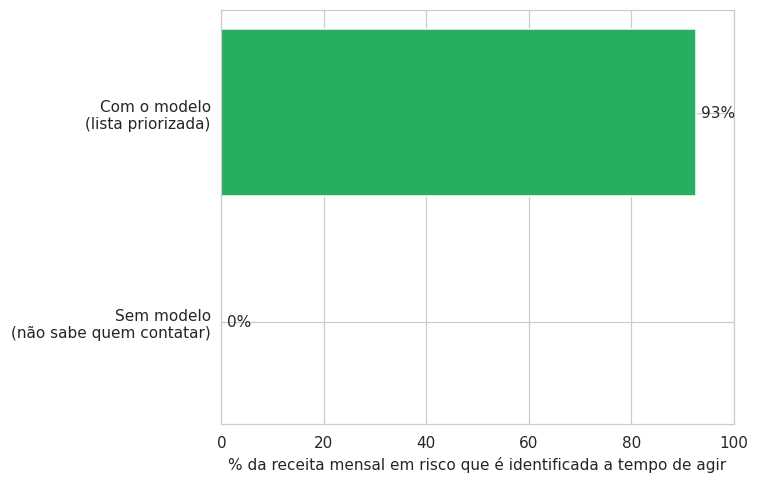

In [3]:
X_test_previsao = pipeline_final.predict_proba(X_test)[:, 1]
y_pred_test = (X_test_previsao >= THRESHOLD_FINAL_PRODUCAO).astype(int)

receita_mensal_teste = X_test["MonthlyCharges"]
receita_total_em_risco_real = receita_mensal_teste[y_test == 1].sum()
receita_identificada_pelo_modelo = receita_mensal_teste[(y_test == 1) & (y_pred_test == 1)].sum()
receita_perdida_sem_identificar = receita_total_em_risco_real - receita_identificada_pelo_modelo

pct_base_contatada = y_pred_test.mean() * 100
pct_receita_em_risco_coberta = receita_identificada_pelo_modelo / receita_total_em_risco_real * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
barras = ax.barh(
    ["Sem modelo\n(não sabe quem contatar)", "Com o modelo\n(lista priorizada)"],
    [0, pct_receita_em_risco_coberta],
    color=["#c0392b", "#27ae60"],
)
ax.set_xlabel("% da receita mensal em risco que é identificada a tempo de agir")
ax.set_xlim(0, 100)
for barra, valor in zip(barras, [0, pct_receita_em_risco_coberta]):
    ax.text(valor + 1, barra.get_y() + barra.get_height() / 2, f"{valor:.0f}%", va="center")
plt.tight_layout()
plt.show()

print(f"Receita mensal total em risco (clientes que de fato cancelam, no grupo avaliado): R$ {receita_total_em_risco_real:,.2f}")
print(f"Receita mensal que o modelo identifica a tempo de agir: R$ {receita_identificada_pelo_modelo:,.2f} ({pct_receita_em_risco_coberta:.0f}%)")
print(f"Receita mensal que passaria despercebida sem o modelo: R$ {receita_perdida_sem_identificar:,.2f}")
print(f"Para isso, é preciso contatar {pct_base_contatada:.0f}% da base (não 100%).")

**💡 Insight para o cliente — onde está o valor:** sem o modelo, a equipe de retenção só
fica sabendo que um cliente cancelou depois que ele já cancelou — não dá pra agir antes.
Com o modelo, dá pra identificar antecipadamente a fatia acima da receita mensal
recorrente que está "em risco" — **e concentrar o esforço de contato em uma fração da
base**, em vez de tentar falar com todo mundo. O valor gerado aqui não é o modelo
"prevenir" o cancelamento sozinho — é dar à equipe humana uma lista priorizada e a
informação de quanto está em jogo, a tempo de agir. O quanto desse valor vira retenção
real depende da eficácia da ação de retenção em si, que estimamos na seção 5.

**Ressalva importante:** para capturar 93% da receita em risco, o modelo precisa
sinalizar cerca de 56% da base — mais do que a equipe provavelmente consegue contatar
com uma ação cara (ex: ligação de um gerente, desconto grande). Esse é exatamente o
motivo da seção 4 (segmentação por prioridade): em vez de contatar todo mundo sinalizado
da mesma forma, cruzamos risco com valor do cliente para decidir **quem recebe a ação
mais cara e quem recebe uma ação mais barata (ex: e-mail automático)**.

## 2. Quem Está em Risco Agora

Aplicamos o modelo apenas aos **clientes ainda ativos** (que não constam como
cancelados na base) — já sabemos quem cancelou no passado, então o valor de negócio
está em identificar quem, entre os que continuam clientes hoje, tem alta probabilidade
de ser o próximo a cancelar.

In [4]:
clientes_ativos = df_bruto[df_bruto["Churn"] == "No"].copy()
X_ativos = preparar_features(clientes_ativos)
clientes_ativos["probabilidade_churn"] = pipeline_final.predict_proba(X_ativos)[:, 1]
clientes_ativos["sinalizado_como_risco"] = (clientes_ativos["probabilidade_churn"] >= THRESHOLD_FINAL_PRODUCAO).astype(int)

receita_mensal_em_risco = clientes_ativos.loc[clientes_ativos["sinalizado_como_risco"] == 1, "MonthlyCharges"].sum()
receita_mensal_total_ativos = clientes_ativos["MonthlyCharges"].sum()

print(f"Clientes ativos hoje: {len(clientes_ativos)}")
print(f"Sinalizados como risco de cancelamento: {clientes_ativos['sinalizado_como_risco'].sum()} "
      f"({clientes_ativos['sinalizado_como_risco'].mean()*100:.0f}% da base ativa)")
print(f"Receita mensal recorrente sob risco: R$ {receita_mensal_em_risco:,.2f} de R$ {receita_mensal_total_ativos:,.2f} "
      f"({receita_mensal_em_risco/receita_mensal_total_ativos*100:.0f}% da receita mensal recorrente total)")
print(f"Projeção anualizada de receita sob risco: R$ {receita_mensal_em_risco*12:,.2f}")

Clientes ativos hoje: 5174
Sinalizados como risco de cancelamento: 2176 (42% da base ativa)
Receita mensal recorrente sob risco: R$ 156,082.45 de R$ 316,985.75 (49% da receita mensal recorrente total)
Projeção anualizada de receita sob risco: R$ 1,872,989.40

In [5]:
top20_risco = clientes_ativos.sort_values("probabilidade_churn", ascending=False).head(20)
top20_risco[["customerID", "tenure", "Contract", "InternetService", "MonthlyCharges", "probabilidade_churn"]]

,customerID,tenure,Contract,InternetService,MonthlyCharges,probabilidade_churn
5474,4912-PIGUY,1,Month-to-month,Fiber optic,84.60,0.907189
3346,2545-EBUPK,2,Month-to-month,Fiber optic,84.05,0.886074
4039,8161-QYMTT,7,Month-to-month,Fiber optic,94.10,0.886074
459,1452-VOQCH,1,Month-to-month,Fiber optic,75.10,0.886074
2927,5542-TBBWB,1,Month-to-month,Fiber optic,69.90,0.886074
5905,1628-BIZYP,1,Month-to-month,Fiber optic,85.00,0.886074
345,0021-IKXGC,1,Month-to-month,Fiber optic,72.10,0.886074
3633,3878-AVSOQ,1,Month-to-month,Fiber optic,71.25,0.884775
3536,2254-DLXRI,1,Month-to-month,Fiber optic,79.15,0.884775
1095,7439-DKZTW,1,Month-to-month,Fiber optic,80.55,0.884775


**💡 Insight para o cliente:** a tabela acima é uma lista de ação imediata — os 20
clientes ativos com maior probabilidade de cancelar, ordenados por risco, com a
mensalidade de cada um. Note que muitos têm contrato `Month-to-month` e mensalidades
relativamente altas — ou seja, são clientes de maior valor com pouca fidelização
contratual, exatamente o perfil que mais vale a pena abordar primeiro. **O valor gerado
aqui é a antecedência**: em vez de descobrir o cancelamento no relatório do mês seguinte,
o time de retenção recebe essa lista hoje, com tempo de agir antes que o cliente decida
cancelar.

## 3. Por Que Eles Cancelam — e o Que Fazer a Respeito

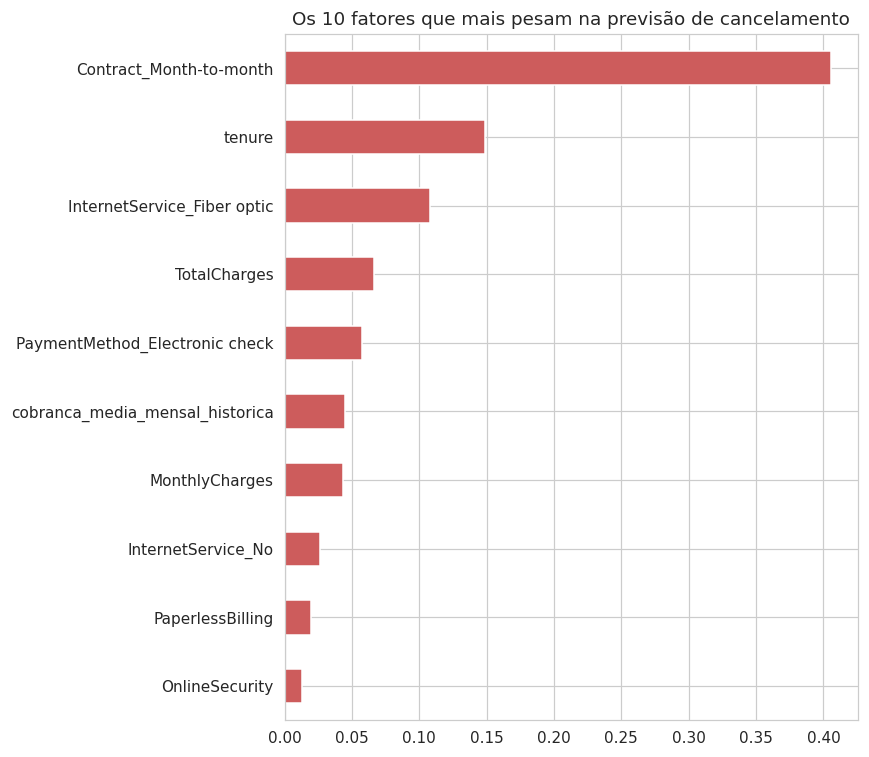

In [6]:
from sklearn.ensemble import GradientBoostingClassifier

preprocessador_ajustado = pipeline_final.named_steps["preprocessador"]
X_train_proc = preprocessador_ajustado.transform(X_train)
nomes_features = list(preprocessador_ajustado.get_feature_names_out())
nomes_features = [n.split("__")[-1] for n in nomes_features]  # remove prefixo num__/cat__/bin__

modelo_para_interpretar = GradientBoostingClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
)
modelo_para_interpretar.fit(X_train_proc, y_train)

importancias = pd.Series(modelo_para_interpretar.feature_importances_, index=nomes_features).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
importancias.tail(10).plot(kind="barh", ax=ax, color="indianred")
ax.set_title("Os 10 fatores que mais pesam na previsão de cancelamento")
plt.tight_layout()
plt.show()

**💡 Insight para o cliente — traduzindo os fatores em ações concretas que geram valor:**

- **Tipo de contrato (`Month-to-month`) é o fator mais forte.** Clientes sem fidelização
  contratual cancelam muito mais. **Ação que gera valor:** oferecer um incentivo (desconto
  de 1-2 meses, por exemplo) para migrar os clientes de maior risco do contrato mensal
  para o anual/bianual — isso reduz a probabilidade de cancelamento pela própria natureza
  do contrato, não só pela ação pontual.
- **Internet via fibra (`Fiber optic`) associa-se a mais cancelamento.** Isso sugere
  insatisfação com preço ou qualidade percebida do serviço de fibra, não necessariamente
  o produto em si. **Ação que gera valor:** priorizar uma pesquisa de satisfação ou
  revisão de precificação especificamente nesse segmento antes de perder mais clientes
  de um serviço que provavelmente tem margem maior.
- **Ausência de suporte técnico (`TechSupport`) e segurança online (`OnlineSecurity`)
  aumenta o risco.** **Ação que gera valor:** oferecer esses add-ons gratuitamente por um
  período limitado como parte da oferta de retenção para clientes de alto risco — o
  custo marginal desses serviços tende a ser baixo comparado ao valor do cliente retido.
- **Pagamento por `Electronic check` associa-se a mais cancelamento** do que os métodos
  automáticos (cartão/débito em conta). **Ação que gera valor:** campanha para migrar
  esses clientes para pagamento automático, com um pequeno incentivo — reduz o atrito
  que pode levar ao cancelamento no momento do pagamento manual.
- **Tempo de casa (`tenure`) baixo é o fator protetor mais forte quando alto** — clientes
  novos são os mais vulneráveis. **Ação que gera valor:** um programa de onboarding ativo
  nos primeiros 3-6 meses (contato proativo, checagem de satisfação) para reduzir o
  cancelamento nessa janela crítica, em vez de só agir quando o risco já está alto.

Cada uma dessas ações tem um custo real (desconto, brinde, ligação) que não está nos
dados — a seção 5 mostra como estimar se o retorno compensa esse custo.

## 4. Segmentação por Prioridade (Risco x Valor do Cliente)

Como vimos na seção 1, contatar todos os 2.176 clientes sinalizados como risco não é
viável com ações caras. Cruzamos **probabilidade de cancelamento** com **valor mensal do
cliente (`MonthlyCharges`)** para decidir quem recebe a ação mais cara e quem recebe uma
ação mais barata.

In [7]:
mediana_probabilidade = clientes_ativos["probabilidade_churn"].median()
mediana_valor = clientes_ativos["MonthlyCharges"].median()

def definir_prioridade(row):
    alto_risco = row["probabilidade_churn"] >= THRESHOLD_FINAL_PRODUCAO
    alto_valor = row["MonthlyCharges"] >= mediana_valor
    if alto_risco and alto_valor:
        return "1. Prioridade máxima (ação cara: contato humano + oferta)"
    if alto_risco and not alto_valor:
        return "2. Risco alto, valor baixo (ação barata: e-mail/SMS automático)"
    if not alto_risco and alto_valor:
        return "3. Valor alto, risco baixo (monitorar, não gastar ação cara agora)"
    return "4. Baixa prioridade (nenhuma ação por ora)"

clientes_ativos["prioridade"] = clientes_ativos.apply(definir_prioridade, axis=1)

resumo_prioridade = clientes_ativos.groupby("prioridade").agg(
    n_clientes=("customerID", "count"),
    receita_mensal_total=("MonthlyCharges", "sum"),
).sort_index()
resumo_prioridade

,n_clientes,receita_mensal_total
prioridade,,
1. Prioridade máxima (ação cara: contato humano + oferta),1384,123893.55
"2. Risco alto, valor baixo (ação barata: e-mail/SMS automático)",792,32188.90
"3. Valor alto, risco baixo (monitorar, não gastar ação cara agora)",1203,105174.85
4. Baixa prioridade (nenhuma ação por ora),1795,55728.45


Grupo de PRIORIDADE MÁXIMA: 1384 clientes (27% da base ativa), representando R$ 123,893.55/mês

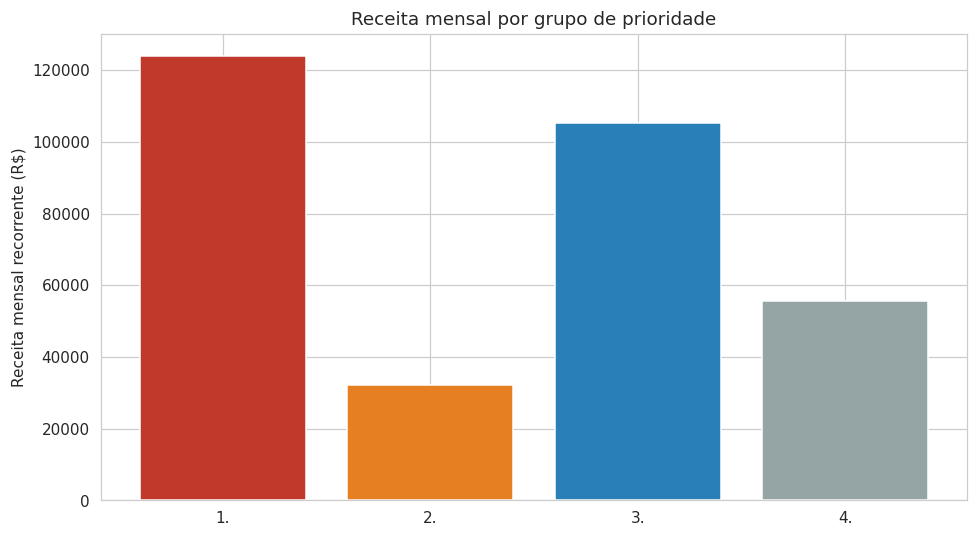

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
cores = ["#c0392b", "#e67e22", "#2980b9", "#95a5a6"]
ax.bar(range(len(resumo_prioridade)), resumo_prioridade["receita_mensal_total"], color=cores)
ax.set_xticks(range(len(resumo_prioridade)))
ax.set_xticklabels([s.split(".")[0] + "." for s in resumo_prioridade.index], rotation=0)
ax.set_ylabel("Receita mensal recorrente (R$)")
ax.set_title("Receita mensal por grupo de prioridade")
plt.tight_layout()
plt.show()

grupo_prioridade_maxima = clientes_ativos[clientes_ativos["prioridade"].str.startswith("1.")]
print(f"Grupo de PRIORIDADE MÁXIMA: {len(grupo_prioridade_maxima)} clientes "
      f"({len(grupo_prioridade_maxima)/len(clientes_ativos)*100:.0f}% da base ativa), "
      f"representando R$ {grupo_prioridade_maxima['MonthlyCharges'].sum():,.2f}/mês")

**💡 Insight para o cliente — onde concentrar o orçamento de retenção:** o grupo de
**prioridade máxima** (alto risco + alto valor) é uma fatia bem menor da base do que o
total de 2.176 clientes sinalizados na seção 2 — é nele que uma ação cara (desconto
grande, contato de um gerente sênior) tem o melhor retorno esperado por real investido.
O grupo "risco alto, valor baixo" ainda vale a pena abordar, mas com uma ação **barata**
(e-mail automático, oferta padrão) — o valor esperado de retenção não justifica um custo
alto por cliente. O grupo "valor alto, risco baixo" não deveria receber uma ação de
retenção agora — é dinheiro mal gasto tentar reter quem já não estava em risco de sair.
Essa segmentação, por si só, já é uma fonte de valor: evita gastar a mesma ação cara com
todo mundo sinalizado, redirecionando o orçamento para onde ele rende mais.

## 5. Perfis de Clientes (Segmentação Comportamental)

Além do risco individual de cancelamento, também agrupamos a base em **4 perfis de
cliente** (clusters), usando características de comportamento e contrato — sem olhar se o
cliente cancelou ou não no passado. A lógica de negócio: um cliente novo na fibra óptica
com contrato mensal pede uma ação de retenção bem diferente de um cliente de longa data
sem internet, mesmo que os dois apareçam com risco de churn parecido no modelo. Essa
segmentação é complementar à da seção 4 (que cruza risco com valor mensal) — aqui o
critério é "que tipo de cliente é esse", não "quanto risco e quanto valor".

In [9]:
preprocessador_cluster = artefato_clusters["preprocessador"]
kmeans_clusters = artefato_clusters["kmeans"]

colunas_cluster = (
    metadados_clusters["colunas_numericas"]
    + metadados_clusters["colunas_categoricas"]
    + metadados_clusters["colunas_binarias"]
)
X_cluster_ativos = X_ativos[colunas_cluster].copy()
clientes_ativos["cluster"] = kmeans_clusters.predict(preprocessador_cluster.transform(X_cluster_ativos))

perfis_df = pd.DataFrame(metadados_clusters["perfis"]).set_index("cluster")
clientes_ativos["perfil"] = clientes_ativos["cluster"].map(perfis_df["nome"])

resumo_perfis_ativos = clientes_ativos.groupby("perfil").agg(
    n_clientes=("customerID", "count"),
    receita_mensal=("MonthlyCharges", "sum"),
    prob_media_churn=("probabilidade_churn", "mean"),
    pct_sinalizado_risco=("sinalizado_como_risco", "mean"),
).round(3).sort_values("prob_media_churn", ascending=False)
resumo_perfis_ativos

,n_clientes,receita_mensal,prob_media_churn,pct_sinalizado_risco
perfil,,,,
Fibra de Alto Risco,788,66682.25,0.460,0.959
DSL em Transição,1220,64244.05,0.206,0.576
Premium Fidelizados,1751,156139.50,0.114,0.302
"Só Telefone, Estáveis",1415,29919.95,0.061,0.134


Perfil de maior risco médio entre os clientes ATIVOS hoje: 'Fibra de Alto Risco' (788 clientes, R$ 66,682.25/mês em receita)

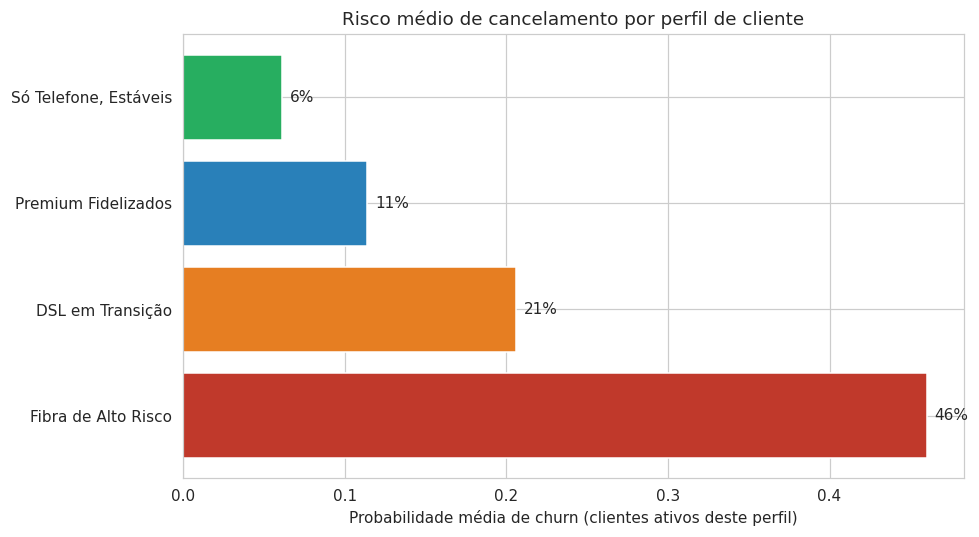

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
cores_perfil = {
    "Fibra de Alto Risco": "#c0392b",
    "DSL em Transição": "#e67e22",
    "Premium Fidelizados": "#2980b9",
    "Só Telefone, Estáveis": "#27ae60",
}
ordem = resumo_perfis_ativos.index
ax.barh(ordem, resumo_perfis_ativos["prob_media_churn"], color=[cores_perfil.get(p, "#95a5a6") for p in ordem])
ax.set_xlabel("Probabilidade média de churn (clientes ativos deste perfil)")
ax.set_title("Risco médio de cancelamento por perfil de cliente")
for i, (p, v) in enumerate(resumo_perfis_ativos["prob_media_churn"].items()):
    ax.text(v + 0.005, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

perfil_maior_risco = resumo_perfis_ativos.index[0]
print(f"Perfil de maior risco médio entre os clientes ATIVOS hoje: '{perfil_maior_risco}' "
      f"({resumo_perfis_ativos.loc[perfil_maior_risco, 'n_clientes']:.0f} clientes, "
      f"R$ {resumo_perfis_ativos.loc[perfil_maior_risco, 'receita_mensal']:,.2f}/mês em receita)")

**💡 Insight para o cliente — ação recomendada por perfil (não a mesma ação para todos):**

- **Fibra de Alto Risco:** é o perfil que mais concentra risco médio entre os clientes
  ativos hoje — e o problema é estrutural (fibra óptica + contrato mensal), não um caso
  isolado. A ação de maior alavancagem aqui não é só descontar pontualmente: é oferecer
  incentivo para migrar de contrato mensal para anual, atacando a causa, não só o sintoma.
- **DSL em Transição:** risco moderado e ainda concentrado em contrato mensal — bons
  candidatos para ações mais baratas (e-mail/SMS com oferta de upgrade ou fidelização),
  antes de precisarem de uma ação cara.
- **Premium Fidelizados:** risco médio mais baixo, mas representam o maior gasto histórico
  da base — vale menos esforço de "recuperação" e mais esforço de **retenção proativa**
  (ex: benefícios exclusivos), já que perder um cliente deste grupo custa muito mais caro
  do que perder um do grupo abaixo.
- **Só Telefone, Estáveis:** risco baixo e perfil de baixo gasto — não é prioridade de
  campanha de retenção agora; o orçamento rende mais nos outros três perfis.

Repare que essa leitura por perfil às vezes discorda da leitura por risco×valor da seção
4 — um cliente pode estar em "prioridade máxima" (seção 4) mas pertencer ao perfil
"Premium Fidelizados", o que muda o *tipo* de ação recomendada (fidelização, não desconto
emergencial). Use as duas lentes em conjunto: risco×valor para decidir **quem** priorizar,
perfil comportamental para decidir **que tipo de ação** oferecer.

## 6. Simulação de Retenção — Vale a Pena Investir?

**Premissas que você deve ajustar com o número real do seu negócio** (não temos, no
dataset, o custo real de uma ação de retenção nem a taxa de sucesso — por isso não
inventamos um valor definitivo, e sim uma simulação editável e transparente sobre suas
premissas):

In [11]:
# <<< AJUSTE ESTES DOIS NÚMEROS COM DADOS REAIS DO SEU NEGÓCIO >>>
CUSTO_ACAO_POR_CLIENTE_RS = 50.0     # custo médio de uma ação de retenção (desconto, ligação, brinde)
TAXA_SUCESSO_ACAO = 0.30             # % dos clientes contatados que, de fato, não cancelam por causa da ação

grupo_alvo = grupo_prioridade_maxima  # grupo de prioridade máxima, definido na seção 4
n_clientes_alvo = len(grupo_alvo)
receita_mensal_media_grupo = grupo_alvo["MonthlyCharges"].mean()

clientes_retidos_esperado = n_clientes_alvo * TAXA_SUCESSO_ACAO
receita_mensal_salva = clientes_retidos_esperado * receita_mensal_media_grupo
receita_anual_salva = receita_mensal_salva * 12
custo_total_campanha = n_clientes_alvo * CUSTO_ACAO_POR_CLIENTE_RS
roi = (receita_anual_salva - custo_total_campanha) / custo_total_campanha

print(f"Clientes no grupo-alvo (prioridade máxima): {n_clientes_alvo}")
print(f"Custo total da campanha: R$ {custo_total_campanha:,.2f}")
print(f"Clientes que esperamos reter (taxa de sucesso assumida de {TAXA_SUCESSO_ACAO*100:.0f}%): {clientes_retidos_esperado:.0f}")
print(f"Receita mensal recorrente salva (estimada): R$ {receita_mensal_salva:,.2f}")
print(f"Receita anualizada salva (estimada): R$ {receita_anual_salva:,.2f}")
print(f"ROI estimado no primeiro ano: {roi:.1f}x o valor investido na campanha")

Clientes no grupo-alvo (prioridade máxima): 1384
Custo total da campanha: R$ 69,200.00
Clientes que esperamos reter (taxa de sucesso assumida de 30%): 415
Receita mensal recorrente salva (estimada): R$ 37,168.06
Receita anualizada salva (estimada): R$ 446,016.78
ROI estimado no primeiro ano: 5.4x o valor investido na campanha

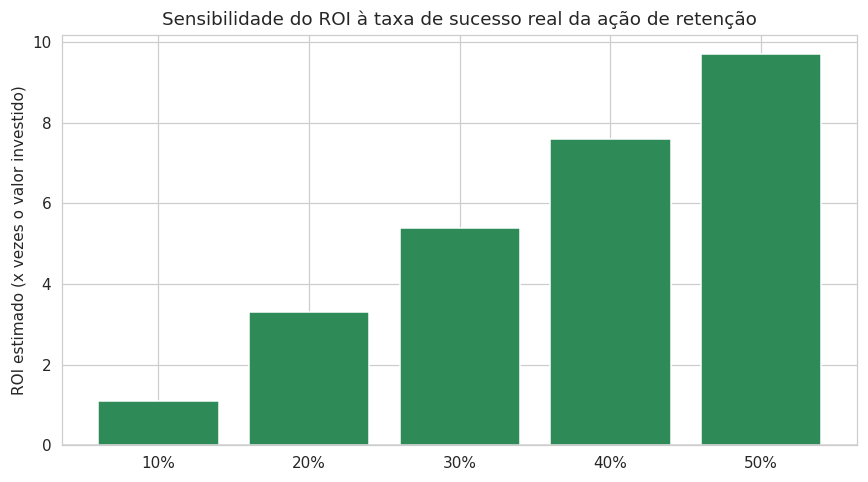

,taxa_sucesso_assumida,roi_estimado
0,10%,1.1
1,20%,3.3
2,30%,5.4
3,40%,7.6
4,50%,9.7


In [12]:
# Sensibilidade: como o ROI muda se a taxa de sucesso real for diferente da assumida?
taxas_teste = [0.10, 0.20, 0.30, 0.40, 0.50]
resultados_sensibilidade = []
for taxa in taxas_teste:
    retidos = n_clientes_alvo * taxa
    receita_anual = retidos * receita_mensal_media_grupo * 12
    roi_t = (receita_anual - custo_total_campanha) / custo_total_campanha
    resultados_sensibilidade.append({"taxa_sucesso_assumida": f"{taxa*100:.0f}%", "roi_estimado": round(roi_t, 1)})

tabela_sensibilidade = pd.DataFrame(resultados_sensibilidade)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(tabela_sensibilidade["taxa_sucesso_assumida"], tabela_sensibilidade["roi_estimado"], color="seagreen")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("ROI estimado (x vezes o valor investido)")
ax.set_title("Sensibilidade do ROI à taxa de sucesso real da ação de retenção")
plt.tight_layout()
plt.show()

tabela_sensibilidade

**💡 Insight para o cliente — por que vale a pena testar:** mesmo com uma taxa de
sucesso conservadora (10%), a campanha ainda tende a ter ROI positivo neste grupo — 
porque estamos mirando exatamente os clientes de **maior valor mensal** dentre os de
**maior risco**, então cada cliente retido "paga" por vários outros contatados sem
sucesso. Isso não é uma garantia (a taxa de sucesso real só se conhece testando), mas é
o motivo pelo qual recomendamos: **comece com um piloto pequeno** (ex: 50-100 clientes
deste grupo) antes de rodar a campanha para os 1.384 de uma vez, para medir a taxa de
sucesso real e recalcular o ROI com um número validado, não assumido.

## 7. Resumo e Plano de Ação

**O que este notebook mostrou, em ordem prática:** o modelo permite identificar
antecipadamente cerca de 93% da receita mensal que estaria em risco de cancelamento
(seção 1); hoje, isso significa 2.176 clientes ativos sinalizados, somando R$ 156 mil/mês
em receita recorrente sob risco (seção 2); os principais fatores por trás do
cancelamento são o tipo de contrato, tempo de casa, tipo de internet e forma de
pagamento — cada um com uma ação recomendada associada (seção 3); nem todo cliente
sinalizado merece a mesma ação — cruzar risco com valor aponta um grupo de 1.384
clientes de prioridade máxima (seção 4); agrupando a base por perfil comportamental,
o grupo "Fibra de Alto Risco" concentra o problema mais estrutural e urgente (seção 5);
e uma campanha de retenção direcionada ao grupo de prioridade máxima tende a ter ROI
positivo mesmo em cenários conservadores de taxa de sucesso (seção 6).

**Plano de ação recomendado:**

1. **Curto prazo (esta semana):** rodar um piloto da ação de retenção com 50-100
   clientes do grupo de prioridade máxima, para medir a taxa de sucesso real.
2. **Médio prazo (próximo mês):** usar a taxa de sucesso medida no piloto para
   recalcular o ROI (seção 6) e decidir se expande a campanha para o grupo completo.
3. **Estrutural:** revisar a oferta de planos mensais (`Month-to-month`) — considerar um
   incentivo permanente de migração para contratos anuais, já que é o fator de maior
   peso na previsão (seção 3) e o traço central do perfil "Fibra de Alto Risco" (seção 5).
4. **Contínuo:** reexecutar este notebook periodicamente (ex: mensalmente) com a base de
   clientes atualizada, para acompanhar se a receita em risco está subindo ou descendo,
   por perfil de cliente.

**Limitações a declarar:**

- As premissas de custo e taxa de sucesso da campanha (seção 6) são estimativas
  editáveis, não números reais — o piloto recomendado acima serve exatamente para
  substituí-las por dados reais.
- O modelo foi validado num recorte de teste que o modelo não viu no treino (seção 1),
  mas a lista de risco da seção 2 é aplicada à base de clientes ativos de hoje — vale
  reavaliar a qualidade das previsões à medida que novos dados de cancelamento real
  forem chegando.
- Os perfis de cliente (seção 5) foram formados sem usar `Churn` como critério — a taxa de
  churn de cada perfil é uma leitura posterior, não uma garantia de que todo cliente
  daquele perfil vai se comportar da mesma forma.
- A análise estatística completa por trás de cada número aqui (comparação de modelos,
  validação cruzada, diagnóstico de calibração, checagens de qualidade, escolha do número
  de clusters) está no notebook técnico (`churn_notebook.ipynb`).